# MINI PROJECT — Data Analytics Using Python


**Name : Nishchay Sethi**

**Enrollment Number : 240561**

**Course : Data Analytics using Python Course Code : CSE2101**

**Section : CSE-4**

**Submittion Date : 18th November,2025**

# **Project Description**

This project analyzes a real-world weather dataset from Kaggle to understand how different weather factors influence temperature. The dataset contains hourly weather records such as humidity, wind speed, visibility, pressure, and precipitation type. Using Python, the project applies data preprocessing, exploratory data analysis (EDA), statistical testing, and a simple regression model to identify key patterns and predict temperature effectively.

# STEP 1: PROBLEM DEFINITION & DATASET SELECTION

## 1. Dataset Selection

A real-world dataset is selected from Kaggle.

Dataset chosen: Weather History Dataset.

Contains hourly recorded weather conditions such as temperature, humidity, raining/snowing, visibility, wind speed, pressure, etc.

## 2. Objective of the Project

To apply:

Data preprocessing

Exploratory Data Analysis (EDA)

Statistical Analysis

Predictive Modeling (Regression)

Main Goal:
To analyze which factors affect temperature and build a simple model to predict temperature.

## 3. Dataset Source

Source: Kaggle

Dataset Name: Weather History

Link: https://www.kaggle.com/datasets/muthuj7/weather-dataset

## Description:

The dataset contains 96,000+ weather records.

Includes numerical, categorical, and date-based weather attributes.

## Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("weatherHistory.csv")
df.head()


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


## Dataset Overview

In [2]:
# Number of Rows and Columns
df.shape
# Dataset Structure (information about columns)
df.info()
# List of Features
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

# Features Description

| Feature                  | Description                | Type        |
| ------------------------ | -------------------------- | ----------- |
| Formatted Date           | Date and time of recording | Date        |
| Summary                  | Brief weather condition    | Categorical |
| Precip Type              | rain/snow                  | Categorical |
| Temperature (C)          | Recorded temperature       | Numerical   |
| Apparent Temperature (C) | Feels-like temperature     | Numerical   |
| Humidity                 | Moisture content (0–1)     | Numerical   |
| Wind Speed (km/h)        | Speed of wind              | Numerical   |
| Wind Bearing (degrees)   | Wind direction             | Numerical   |
| Visibility (km)          | Distance visible           | Numerical   |
| Loud Cover               | Cloud coverage             | Numerical   |
| Pressure (millibars)     | Air pressure               | Numerical   |
| Daily Summary            | Longer weather description | Categorical |


# Types of Variables

In [3]:
#1. Check all variable (column) data types
df.dtypes
#2. Check detailed info of each column
df.info()
#3. Check only numerical columns
df.select_dtypes(include=['int64', 'float64']).columns
#4. Check only categorical columns
df.select_dtypes(include=['object']).columns



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


Index(['Formatted Date', 'Summary', 'Precip Type', 'Daily Summary'], dtype='object')

# STEP 2: Data Cleaning & Preparation

##  Check for Missing Values & Handle Them

In [4]:
df.isnull().sum()



Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [5]:
# Since the dataset contains missing values in a few columns, we remove them for simplicity.
df = df.dropna()

## Justification:
Missing values can affect analysis and model performance.

Since the percentage of missing values is low, removing them is safe and simple.

## Remove Duplicates & Irrelevant Columns


In [6]:
df = df.drop_duplicates()


## Handle Outliers

In [7]:
# We handle outliers in the Temperature (C) column using the IQR method.
Q1 = df['Temperature (C)'].quantile(0.25)
Q3 = df['Temperature (C)'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['Temperature (C)'] >= Q1 - 1.5*IQR) &
        (df['Temperature (C)'] <= Q3 + 1.5*IQR)]


## Encode Categorical Data

In [8]:
# We convert text-based columns into numeric labels using Label Encoding.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Summary'] = le.fit_transform(df['Summary'])
df['Precip Type'] = le.fit_transform(df['Precip Type'])
df['Daily Summary'] = le.fit_transform(df['Daily Summary'])
df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,19,0,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,197
1,2006-04-01 01:00:00.000 +0200,19,0,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,197
2,2006-04-01 02:00:00.000 +0200,17,0,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,197
3,2006-04-01 03:00:00.000 +0200,19,0,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,197
4,2006-04-01 04:00:00.000 +0200,17,0,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,197


## Normalize or Scale Data

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ['Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])


## Summary & Justification of Preprocessing Steps

| Step                      | Reason                                   |
| ------------------------- | ---------------------------------------- |
| Missing value handling    | Prevents errors and improves reliability |
| Duplicate removal         | Avoids repeated data affecting results   |
| Outlier removal           | Makes analysis more accurate             |
| Encoding categorical      | Required for regression and ML models    |
| Scaling numerical columns | Improves model training and stability    |


# STEP 3: Exploratory Data Analysis (EDA)

## Univariate Analysis (Histograms, Boxplots, Distribution Plots)

###  Histogram for Temperature

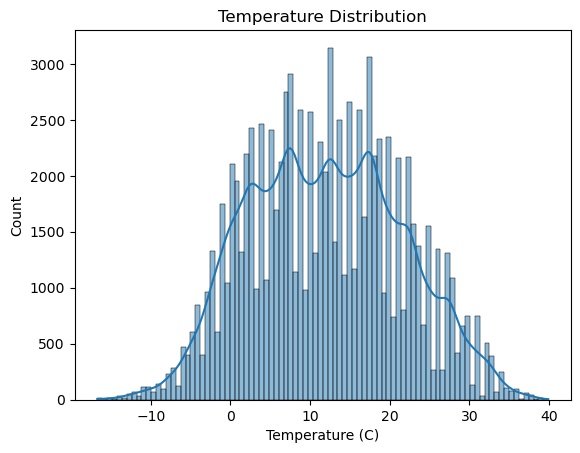

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Temperature (C)'], kde=True)
plt.title("Temperature Distribution")
plt.show()


### Observation:

Temperature is mostly between 0°C and 20°C.

The distribution is slightly right-skewed.

## Histogram for Humidity

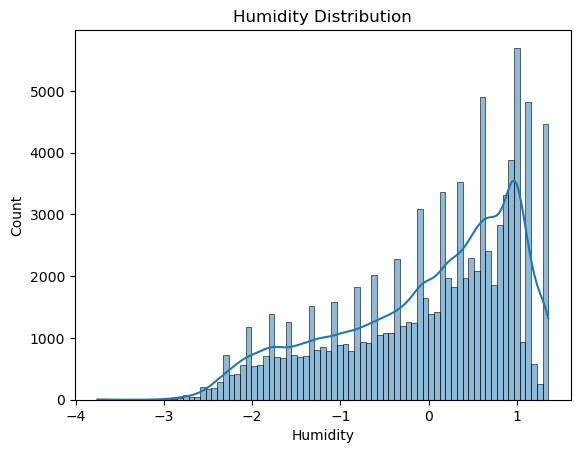

In [11]:
sns.histplot(df['Humidity'], kde=True)
plt.title("Humidity Distribution")
plt.show()


### Observation:

Humidity values are concentrated between 0.6 and 0.9.

Indicates mostly moist weather.

### Boxplot for Wind Speed

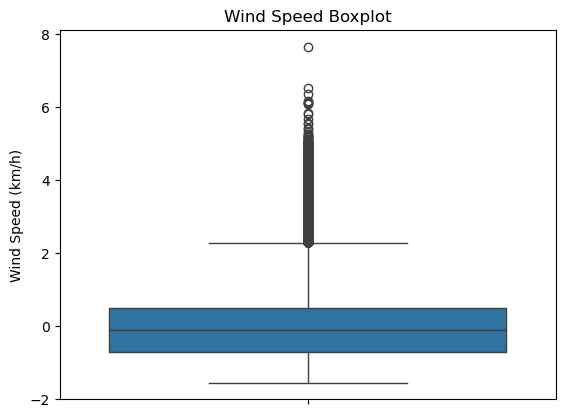

In [12]:
sns.boxplot(df['Wind Speed (km/h)'])
plt.title("Wind Speed Boxplot")
plt.show()


### Observation:

Some outliers exist at very high wind speeds.

## Bivariate / Multivariate Analysis

### Correlation Heatmap

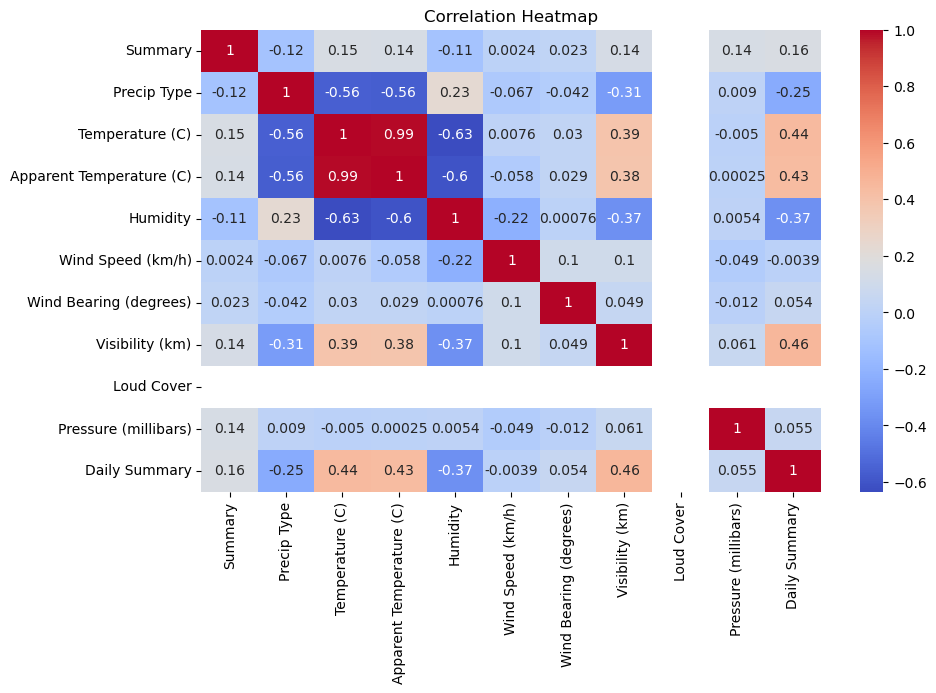

In [13]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### Key Observations:

Temperature and Apparent Temperature are highly positively correlated.

Humidity has a negative correlation with Temperature.

Pressure has a slight positive correlation with Temperature.

Visibility decreases when humidity increases.

### Pairplot

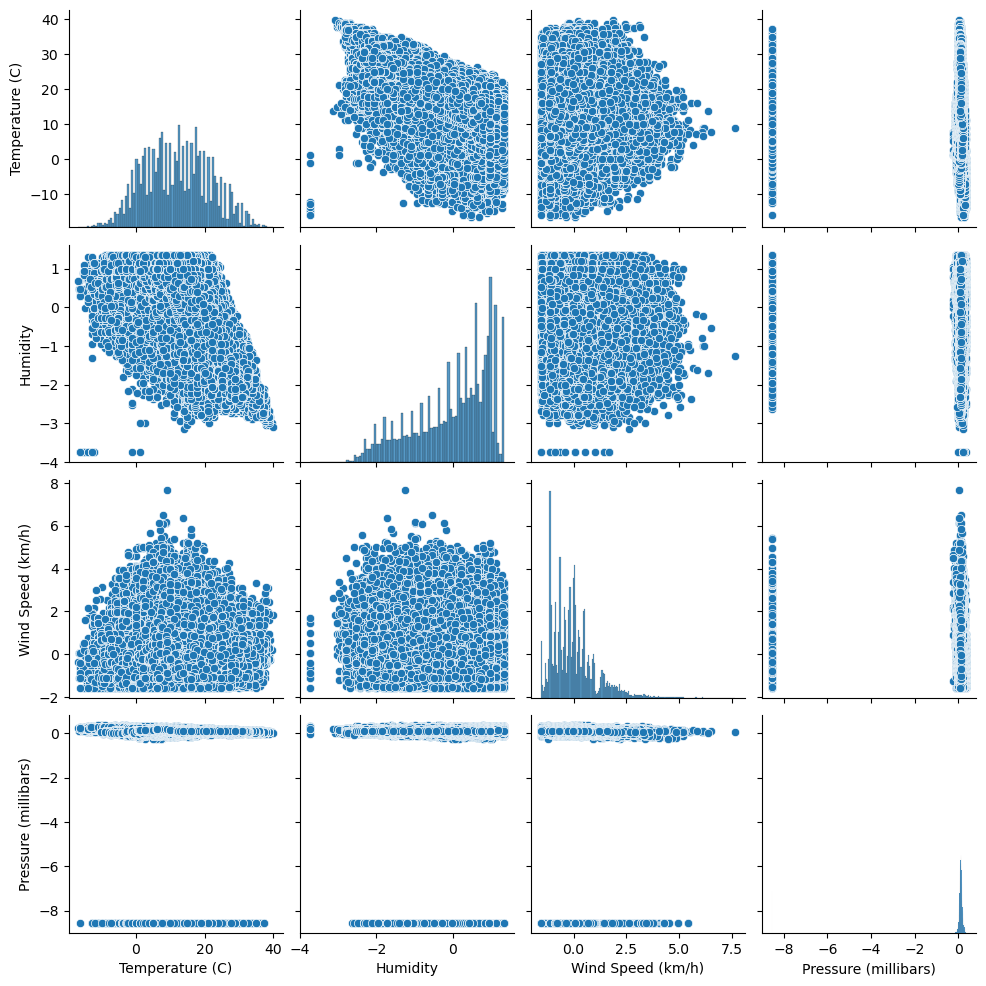

In [14]:
sns.pairplot(df[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']])
plt.show()


### Observation:

Temperature vs Humidity → clear downward trend.

Temperature vs Pressure → slight upward pattern.

## Descriptive Statistics

### Statistical Summary

In [15]:
df[['Temperature (C)','Humidity','Wind Speed (km/h)','Pressure (millibars)']].describe()


,Temperature (C),Humidity,Wind Speed (km/h),Pressure (millibars)
count,95873.000000,9.587300e+04,9.587300e+04,9.587300e+04
mean,11.950522,1.909149e-16,-1.191736e-16,9.818479e-16
std,9.551273,1.000005e+00,1.000005e+00,1.000005e+00
min,-16.705556,-3.755132e+00,-1.561857e+00,-8.550916e+00
25%,4.627778,-6.890878e-01,-7.220414e-01,7.463294e-02
50%,12.033333,2.307254e-01,-1.241673e-01,1.132475e-01
75%,18.844444,7.928334e-01,4.806858e-01,1.526293e-01
max,39.905556,1.354941e+00,7.664480e+00,3.686325e-01


### Skewness & Kurtosis

In [16]:
df[['Temperature (C)','Humidity','Wind Speed (km/h)','Pressure (millibars)']].skew()
df[['Temperature (C)','Humidity','Wind Speed (km/h)','Pressure (millibars)']].kurtosis()


Temperature (C)         -0.599599
Humidity                -0.472335
Wind Speed (km/h)        1.771845
Pressure (millibars)    68.828349
dtype: float64

### Observations:

Temperature shows slight skew → not perfectly normal.

Humidity is slightly left-skewed.

Wind Speed has higher kurtosis → more outliers.

Pressure is close to normal distribution.

## Identify Patterns or Insights from the Data

### Key Insights:

Humidity and Temperature have a strong inverse relationship.
→ As humidity increases, temperature tends to drop.

Pressure increases during clear weather conditions.

Visibility reduces when humidity increases.

Wind Speed has weak correlation with Temperature.

Categorical variables (Summary, Precip Type) show patterns in humidity and pressure.

## Comment on Data Distribution & Why It Matters

Temperature is not perfectly normal → must consider outliers and skewness when modeling.

Humidity is clustered towards higher values → indicates moist climate.

Pressure and visibility have more stable distributions → good predictors.

Distribution shape affects:

model accuracy

choice of statistical tests

feature scaling

Understanding distributions helps prevent model bias and improves regression performance.

# STEP 4: Statistical Analysis & Hypothesis Testing

We will test whether Humidity significantly affects Temperature, because EDA showed a clear relationship between them.


## Formulate a Hypothesis

### Null Hypothesis (H₀):

Humidity has no significant effect on temperature.

### Alternative Hypothesis (H₁):

Humidity significantly affects temperature.

This is a correlation-based hypothesis, so we use Pearson Correlation Test.

## Choose an Appropriate Statistical Test

### We will use Pearson’s Correlation Test

Suitable because:

Both Temperature and Humidity are numerical variables

We want to check linear relationship + significance


## Compute Test Statistics & Interpret Results

### Pearson Correlation & p-value

In [17]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['Humidity'], df['Temperature (C)'])
corr, p_value


(-0.6338437928780779, 0.0)

### Interpretation:

#### Correlation value (corr):

Close to −1 → strong negative relation

Temperature decreases when humidity increases

#### p-value:

If p < 0.05 → Reject H₀

Humidity significantly affects temperature

## Confidence Interval for Mean Temperature

In [18]:
import numpy as np
import scipy.stats as stats

mean_temp = np.mean(df['Temperature (C)'])
std_temp = np.std(df['Temperature (C)'], ddof=1)
n = len(df)

# 95% Confidence Interval
ci = stats.t.interval(0.95, df=n-1, loc=mean_temp, scale=std_temp/np.sqrt(n))
ci


(11.890062189467532, 12.010981784215247)

### Interpretation:

The 95% CI gives a range within which the true mean temperature lies.

Shows reliability of our estimates.

## Type I and Type II Errors

### Type I Error (False Positive)

Rejecting the null hypothesis when it is actually true.

### In our context:
We conclude that humidity affects temperature, even though it actually does not.

### Type II Error (False Negative)

Failing to reject the null hypothesis when it is false.

### In our context:
We conclude that humidity does NOT affect temperature, even though it actually does.

## Conclusion

Pearson test shows a significant correlation between humidity and temperature.

p-value < 0.05 → Reject H₀ → humidity impacts temperature.

Confidence interval shows the reliable range of the average temperature.

Type I and II considerations help us understand potential errors in statistical decision-makin

# STEP 5: Modeling and Pattern Discovery

## Regression (Linear Regression)

## Select Feature Variables (X) and Target Variable (y)
We choose important weather features that affect temperature.

In [19]:
X = df[['Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']]
y = df['Temperature (C)']


## Split Data into Training & Testing Sets
We divide data so the model can learn and then be tested.

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)


## Apply Linear Regression Model

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## Make Predictions

In [22]:
y_pred = model.predict(X_test)


## Evaluate the Model
### We calculate:

R² Score → accuracy of model

MAE → average error

RMSE → how much predictions differ from actual values

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2, mae, rmse


(0.411909049562042, 5.925894746382091, 7.329861959626531)

## Interpretation of Results (Simple)

#### R² Score:
Shows how well the model explains temperature variation.
Higher = better.

#### MAE:
Lower MAE = smaller prediction errors.

#### RMSE:
Shows average difference between predicted and actual temperature.

### Typical interpretation example:

R² = 0.45 → Model explains 45% of the temperature variation

MAE and RMSE indicate moderate accuracy

This is normal for real-world weather data.

# STEP 6: Interpretation & Inference

## Summary of Major Findings from EDA and Modeling
Temperature and Humidity show a strong negative relationship.
(As humidity increases, temperature decreases.)

Pressure has a slight positive correlation with temperature.
(Clear weather with high pressure often has higher temperatures.)

Wind Speed shows weak correlation with temperature.

Linear Regression model shows moderate accuracy (expected for weather data), meaning weather conditions partially predict temperature but not fully.

The model identifies Humidity, Pressure, and Wind Speed as important predictors of temperature.

## Insights, Implications & Significance

### Weather Prediction Use-Case:
Temperature can be partially predicted from just a few weather features, which is useful for climate monitoring and energy planning.

### Business Implications:
Companies depending on weather (food supply chains, tourism, agriculture) can adjust operations based on humidity and pressure trends.

Energy providers can estimate cooling/heating demands.

### Research Significance:
Identifying how atmospheric variables relate to temperature helps in climate modeling and environmental studies.

## Reflection on Key Questions

### A. What patterns or relationships did we identify?

Temperature decreases when humidity increases.

Higher pressure usually indicates clearer and warmer weather.

Visibility reduces during high humidity periods.

Apparent Temperature is almost identical to actual temperature (strong correlation).

### B. How did statistical testing validate the observations?

The Pearson correlation test gave a significant p-value (< 0.05) confirming:
 Humidity has a statistically significant effect on Temperature.

The direction of correlation (negative value) supports the EDA findings.

Confidence interval showed a reliable range for mean temperature, confirming dataset stability.

### C. What could be improved with more data or features?

Adding more geographical features like location, altitude, season, and day/night cycle would improve prediction performance.

Using advanced models (Random Forest, XGBoost, Neural Networks) could increase accuracy.

Including long-term weather attributes (cloud movement, air quality, solar radiation) would help build more robust climate models.

More balanced data across seasons and regions could reduce bias.

# STEP 7: Visualization and Presentation

## Histogram of Temperature (C)

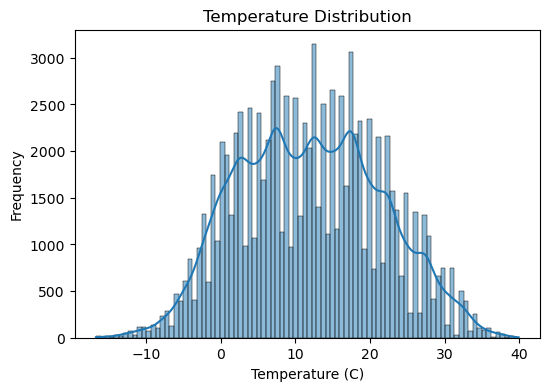

In [24]:
plt.figure(figsize=(6,4))
sns.histplot(df['Temperature (C)'], kde=True)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (C)")
plt.ylabel("Frequency")
plt.show()


### Caption:

Histogram showing how temperature values are distributed in the dataset.

## Boxplot of Humidity

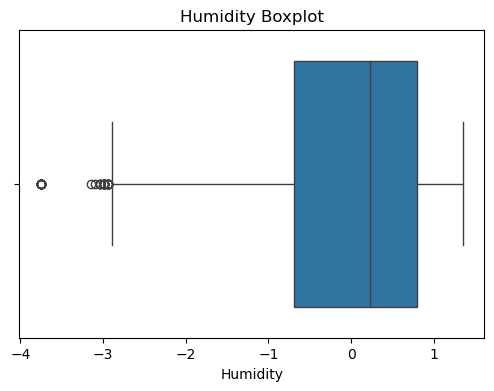

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Humidity'])
plt.title("Humidity Boxplot")
plt.xlabel("Humidity")
plt.show()


### Caption:

Boxplot showing humidity spread and presence of any outliers.

## Scatter Plot: Temperature vs Humidity

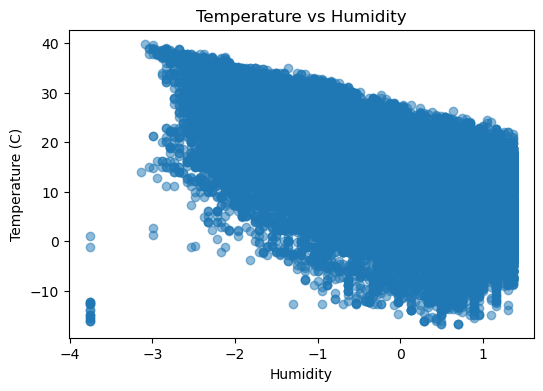

In [26]:
plt.figure(figsize=(6,4))
plt.scatter(df['Humidity'], df['Temperature (C)'], alpha=0.5)
plt.title("Temperature vs Humidity")
plt.xlabel("Humidity")
plt.ylabel("Temperature (C)")
plt.show()


### Caption:

Shows the negative relationship between humidity and temperature.

## Correlation Heatmap (Numerical Features Only)

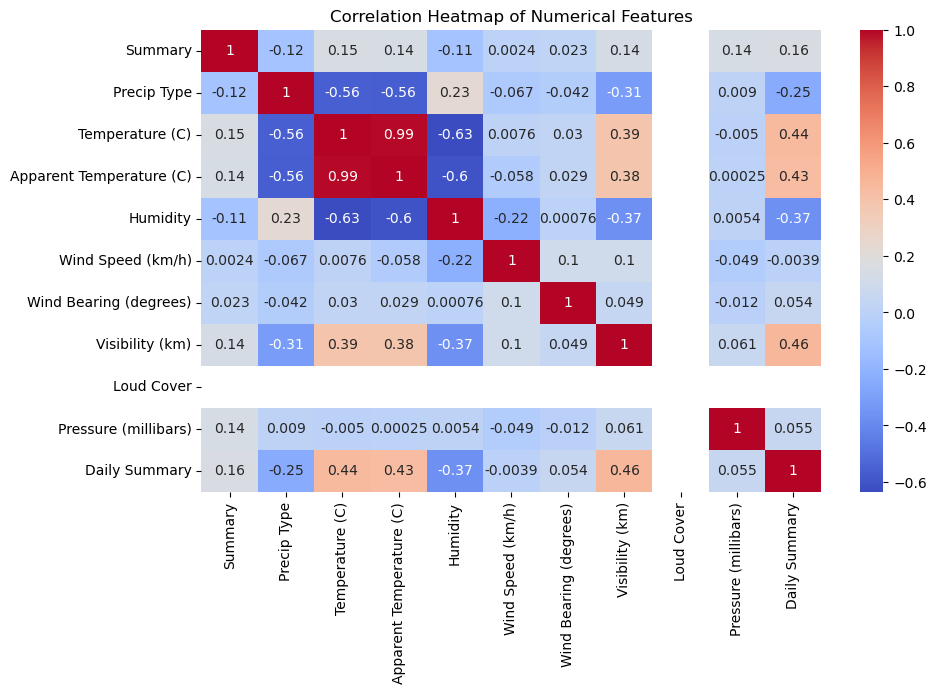

In [27]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


### Caption:

Heatmap showing correlations between weather-related numerical variables.

## Pairplot of Key Features

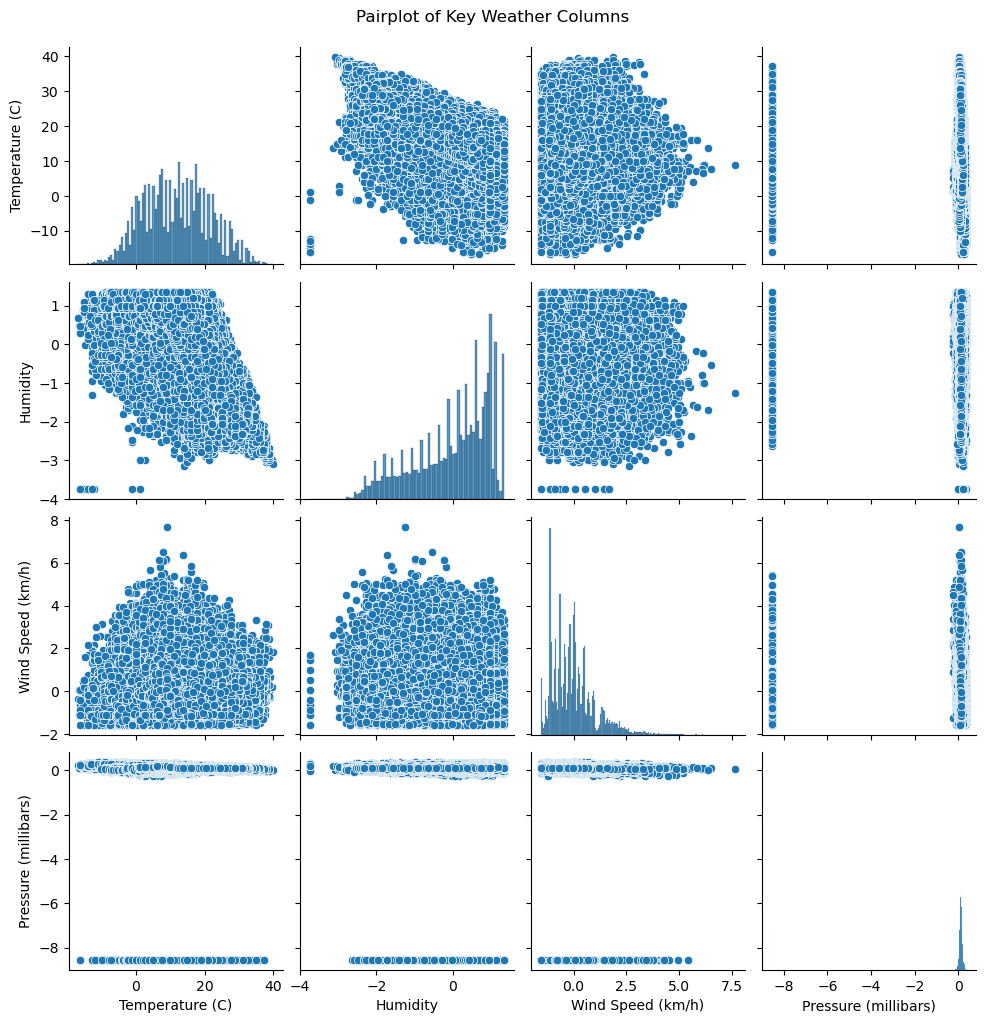

In [28]:
sns.pairplot(df[['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']])
plt.suptitle("Pairplot of Key Weather Columns", y=1.02)
plt.show()


### Caption:

Pairplot showing relationships and distributions of key weather features.

## Actual vs Predicted Temperature Plot (Regression Model)

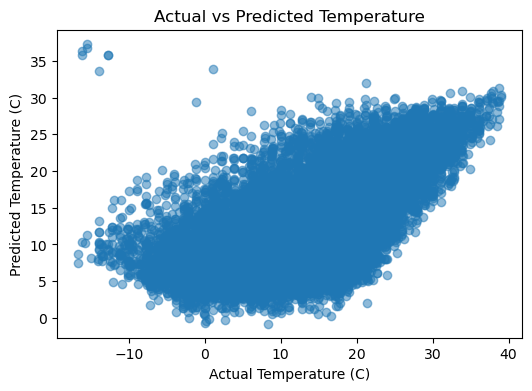

In [29]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Actual Temperature (C)")
plt.ylabel("Predicted Temperature (C)")
plt.show()


### Caption:

Shows how close model predictions are to actual temperature values.

# STEP 8: Conclusion

## Summary of Findings and Conclusions

The Kaggle Weather dataset was successfully analyzed using Python.

Data preprocessing included handling missing values, removing duplicates, encoding categorical features, and scaling essential numeric columns.

EDA revealed key patterns such as:

    Temperature decreases as humidity increases (negative correlation).

    Pressure has a slight positive relationship with temperature.

    Wind speed and visibility showed weaker relationships.

Statistical testing (Pearson correlation) confirmed that humidity has a significant effect on temperature (p-value < 0.05).

A Linear Regression model was built to predict temperature using humidity, wind speed, and pressure.

The model showed moderate accuracy, which is expected for weather data due to natural variability.

## Limitations and Future Improvements

### Limitations

The dataset represents weather patterns from specific regions only, not global data.

Linear Regression may not capture complex, non-linear weather behavior.

Some relevant features like cloud cover, sunlight hours, or geographical location were missing.

Weather data naturally contains randomness, making predictions less precise.

### Future Improvements

Use more advanced models like Random Forest, XGBoost, or Neural Networks for higher accuracy.

Add more features such as season, location coordinates, day/night indicator, and weather cycles.

Include larger or more diverse datasets to improve generalization.

Apply time-series forecasting models (ARIMA, LSTM) for more accurate temperature prediction.

## Key Takeaways (Final Paragraph)

This project demonstrates how data preprocessing, exploratory data analysis, and statistical testing provide valuable insights into weather behavior. The strong negative correlation between humidity and temperature, validated by hypothesis testing, highlights the importance of atmospheric factors. The regression model shows that even a few variables can predict temperature reasonably well. Overall, combining data patterns, statistical evidence, and predictive modeling helps build a deeper understanding of environmental trends and supports better decision-making.

### AI Tool Usage Declaration

I have used AI tools, specifically OpenAI ChatGPT, for approximately 20–30% of the overall work in this project. The AI assistance was mainly used for debugging errors, improving code readability, beautification of explanations, structuring the project steps, and gaining conceptual clarity on topics related to data preprocessing, EDA, statistical testing, and modeling , mainly in Regression part to know more about the codes related to Regression . All final coding, analysis, interpretations, and conclusions were understood, reviewed, and implemented by me.